In [1]:
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account


credentials = service_account.Credentials.from_service_account_file("key.json") # lokalizacja pobranego klucza z punktu 1.4.

client = bigquery.Client(credentials=credentials, project=credentials.project_id)

In [2]:
query = """

select r24_25.*, stations.*

from (

select *
from `bigquery-public-data.noaa_gsod.gsod2023`

union all

select *
from `bigquery-public-data.noaa_gsod.gsod2024`

union all

select *
from `bigquery-public-data.noaa_gsod.gsod2025`

) as r24_25
join `bigquery-public-data.noaa_gsod.stations` as stations on r24_25.stn = stations.usaf and r24_25.wban = stations.wban
"""

query_job = client.query(query)
query_result = query_job.result()
# weather and stations
dfwas = query_result.to_dataframe()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = dfwas.copy()
data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["month"] = data["date"].dt.month
data["mxpsd"] = pd.to_numeric(data["mxpsd"], errors="coerce")

missing_codes = {
    "temp": 9999.9,
    "max": 9999.9,
    "min": 9999.9,
    "dewp": 9999.9,
    "slp": 9999.9,
    "stp": 9999.9,
    "visib": 999.9,
    "wdsp": 999.9,
    "mxpsd": 999.9,
    "gust": 999.9,
    "prcp": 99.99
}

for col, code in missing_codes.items():
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")
        data[col] = data[col].replace(code, np.nan)

sns.set(style="whitegrid")

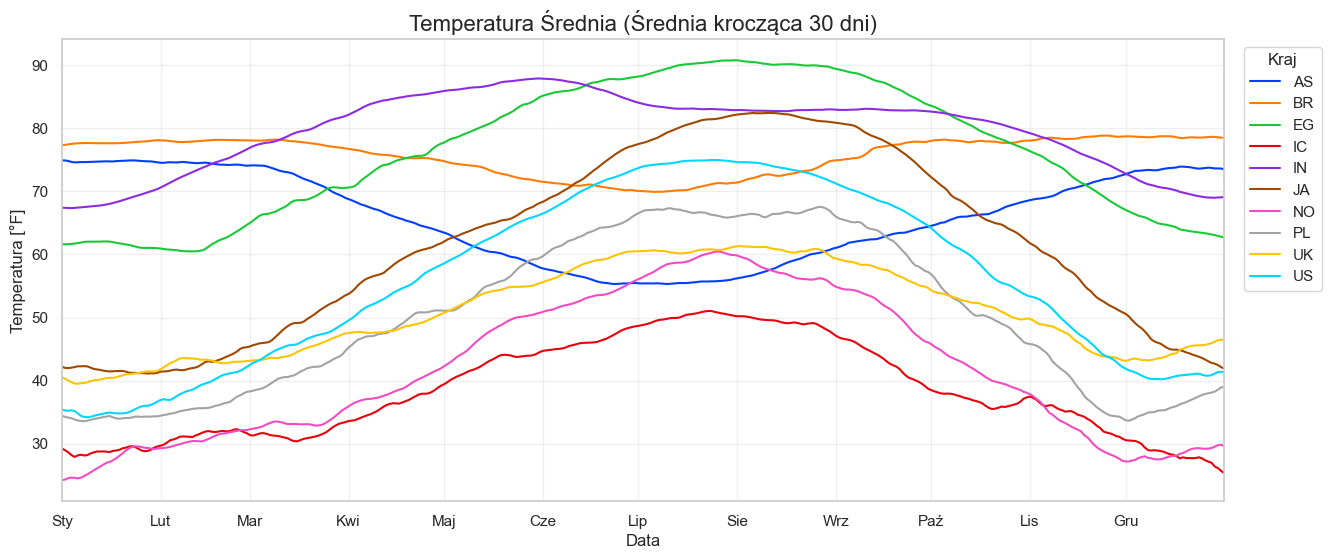

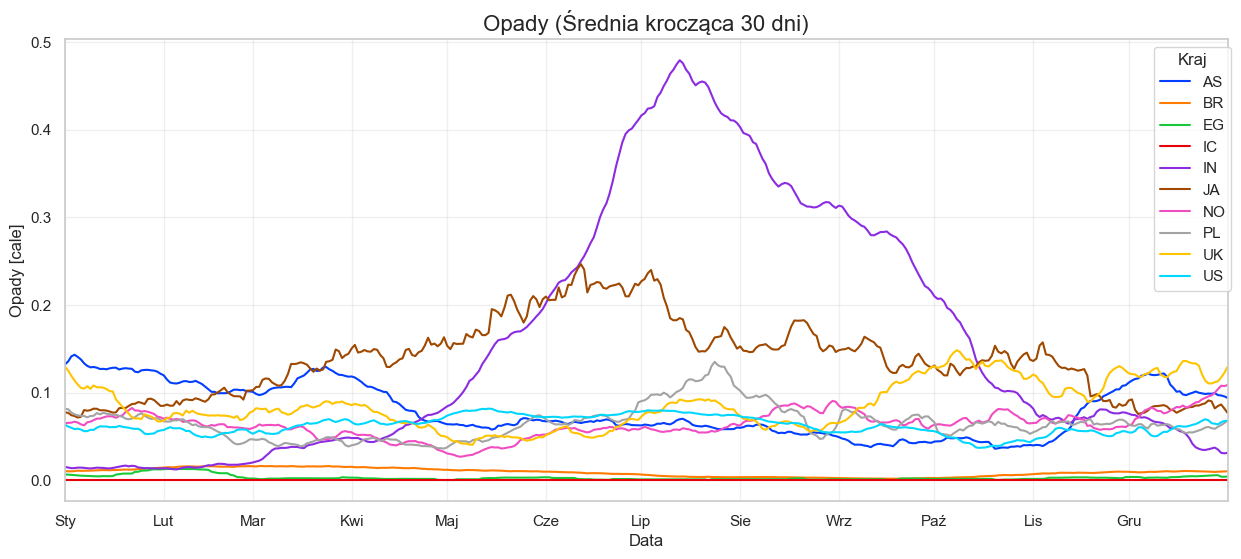

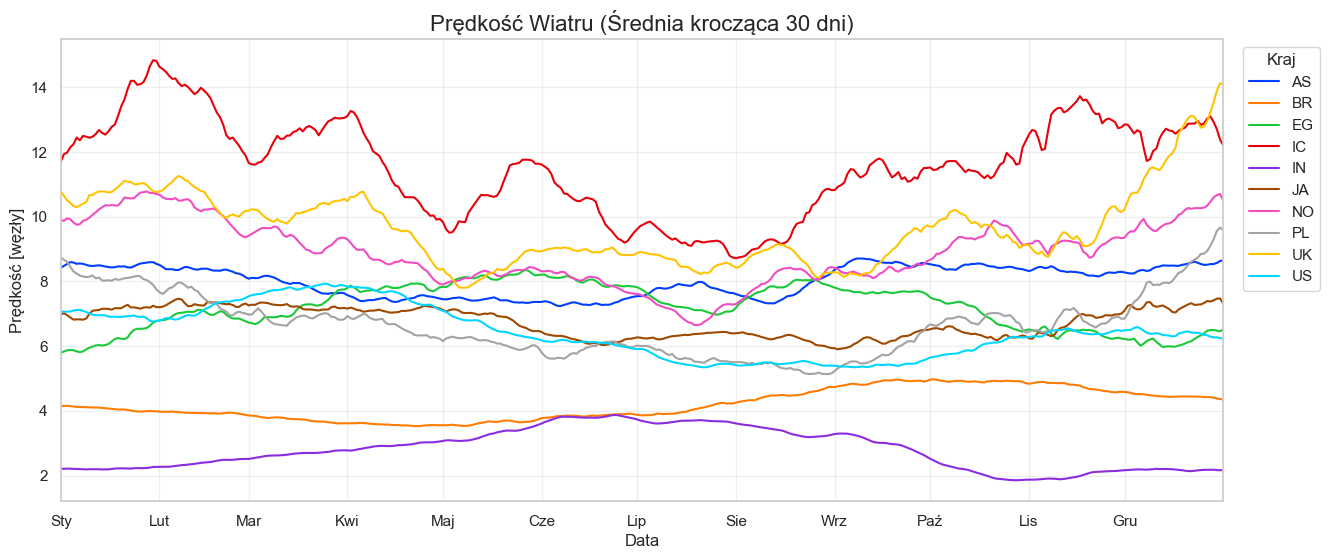

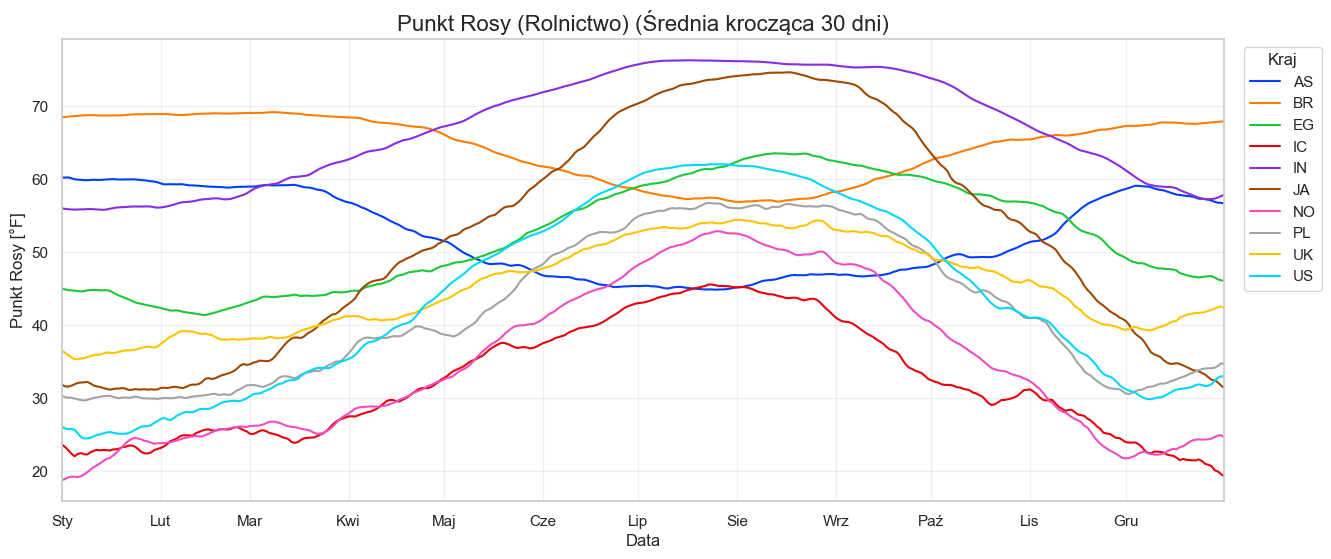

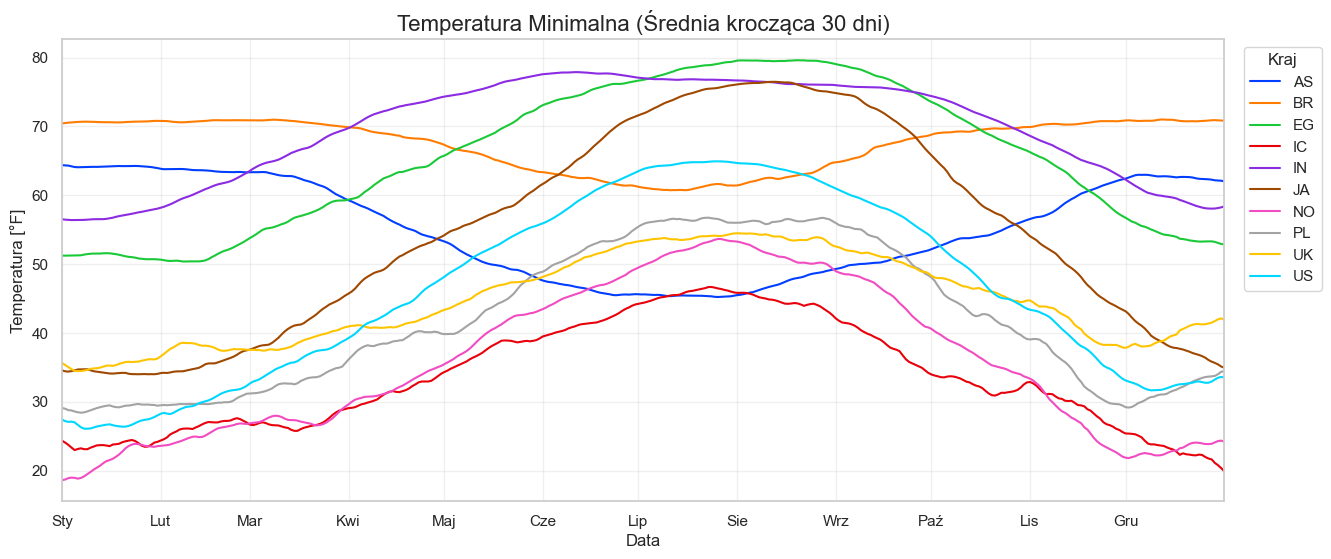

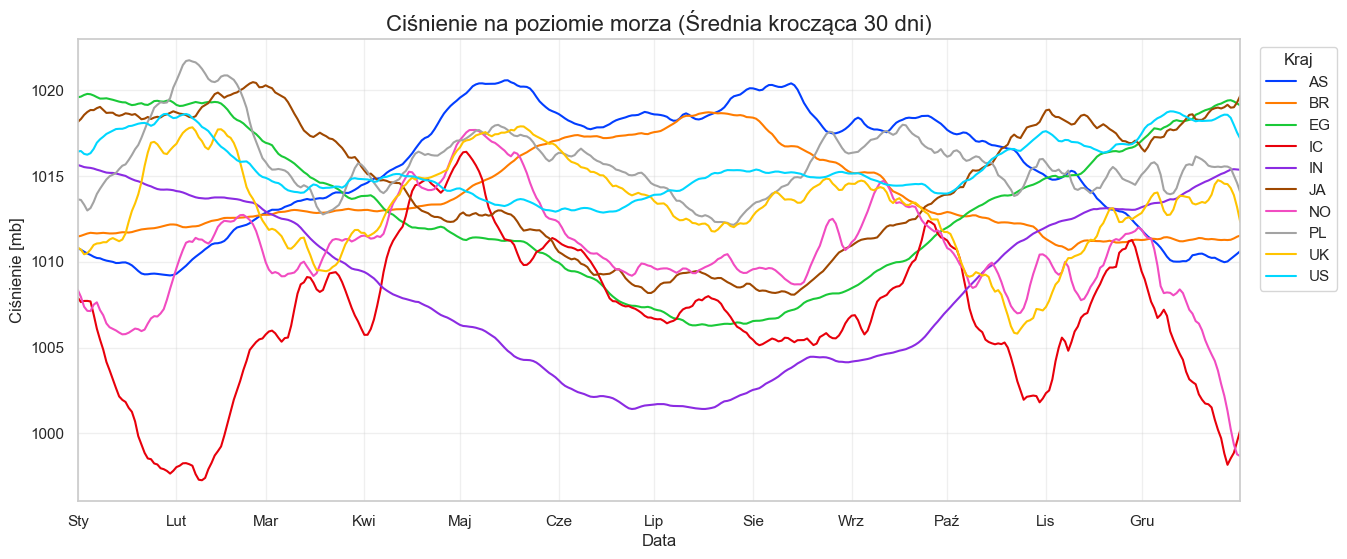

In [4]:
# "PL": "Poland",
# "UK": "United Kingdom of Great Britain and Northern Ireland",
# "NO": "Norway",
# "IC": "Iceland",
# "US": "United States of America",
# "BR": "Brazil",
# "AS": "Australia",
# "IN": "India",
# "JA": "Japan",
# "EG": "Egypt",

countries_to_check = ['PL', 'UK', 'NO', 'IC', 'US', 'BR', 'AS', 'IN', 'JA', 'EG']

data_pkt1 = data[data["country"].isin(countries_to_check)].copy()
data_pkt1['day_of_year'] = data_pkt1['date'].dt.dayofyear

df_daily = data_pkt1.groupby(['country', 'day_of_year']).agg({
    'temp': 'mean',
    'prcp': 'mean',
    'wdsp': 'mean',
    'dewp': 'mean',
    'min': 'mean',
    'slp': 'mean'
}).reset_index()

month_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']


window = 30
cols_to_analyze = ['temp', 'prcp', 'wdsp', 'dewp', 'min', 'slp']
for col in cols_to_analyze:

    df_daily[f'{col}_ma'] = df_daily.groupby('country')[col].transform(
        lambda x: x.rolling(window=window, min_periods=1, center=True).mean()
    )
    df_daily[f'{col}_std'] = df_daily.groupby('country')[col].transform(
        lambda x: x.rolling(window=window, min_periods=1, center=True).std()
    )


def plot_trend(df, column, title, ylabel):
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=df, x='day_of_year', y=f'{column}_ma', hue='country', linewidth=1.5 ,palette='bright')
    plt.xticks(ticks=month_ticks, labels=month_labels)
    plt.xlim(1, 366)


    plt.title(f"{title} (Średnia krocząca {window} dni)", fontsize=16)
    plt.xlabel("Data", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(title="Kraj", bbox_to_anchor=(1.01, 1))
    plt.grid(True, alpha=0.3)
    plt.show()

plot_trend(df_daily, 'temp', 'Temperatura Średnia', 'Temperatura [°F]')
plot_trend(df_daily, 'prcp', 'Opady', 'Opady [cale]')
plot_trend(df_daily, 'wdsp', 'Prędkość Wiatru', 'Prędkość [węzły]')
plot_trend(df_daily, 'dewp', 'Punkt Rosy (Rolnictwo)', 'Punkt Rosy [°F]')
plot_trend(df_daily, 'min', 'Temperatura Minimalna', 'Temperatura [°F]')
plot_trend(df_daily, 'slp', 'Ciśnienie na poziomie morza', 'Ciśnienie [mb]')

NameError: name 'reg' is not defined

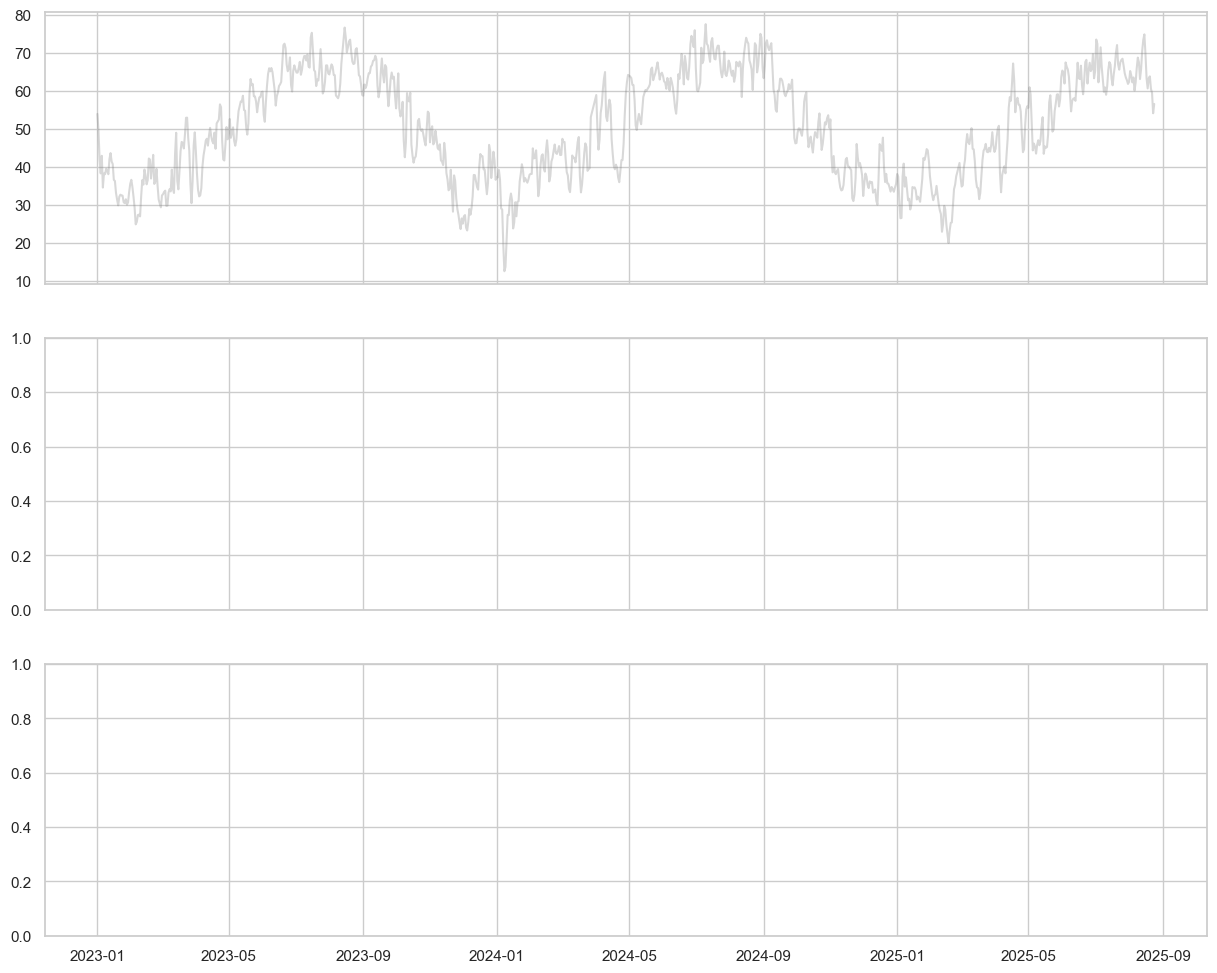

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


df_pl = data[data['country'] == 'PL'].copy()
df_pl = df_pl.groupby('date').agg({
    'temp': 'mean', 'prcp': 'mean', 'wdsp': 'mean',
    'dewp': 'mean', 'min': 'mean'
})

cases = ['temp', 'prcp', 'wdsp', 'dewp', 'min']

for col in cases:
    result = seasonal_decompose(df_pl[col], model='additive', period=365) #dekompozycja cykl roczny
    #sezonowość = dane - trend


    x = np.arange(len(df_pl)) #lista dni
    y = df_pl[col].values #do tablicy numpy
    slope = (np.mean(x * y) - np.mean(x) * np.mean(y)) / np.var(x) #współczynnik = cov(x,y ) / var(x)
    trend_line = slope * (x - np.mean(x)) + np.mean(y) #aby funkcja miała środek w środku dziedziny



    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

    ax1.plot(df_pl.index, y, label='Dane surowe (dzienne)', alpha=0.3, color='gray')
    #
    #Błąd w lini 33 name 'reg' is not defined
    #
    ax1.plot(df_pl.index, trend_line, label=f'Trend liniowy (nachylenie: {reg.coef_[0]:.5f})', color='red', linewidth=2)
    ax1.set_title(f"Analiza dla: {col.upper()} - Metoda: Regresja Liniowa")
    ax1.legend()

    ax2.plot(df_pl.index, result.trend, label='Trend (z dekompozycji)', color='blue', linewidth=2)
    ax2.set_title(f"Metoda: Dekompozycja - Wyizolowany Trend")
    ax2.legend()

    ax3.plot(df_pl.index, result.seasonal, label='Sezonowość (cykl roczny)', color='green')
    ax3.set_title(f"Metoda: Dekompozycja - Wyizolowana Sezonowość")
    ax3.legend()

    plt.tight_layout()
    plt.show()


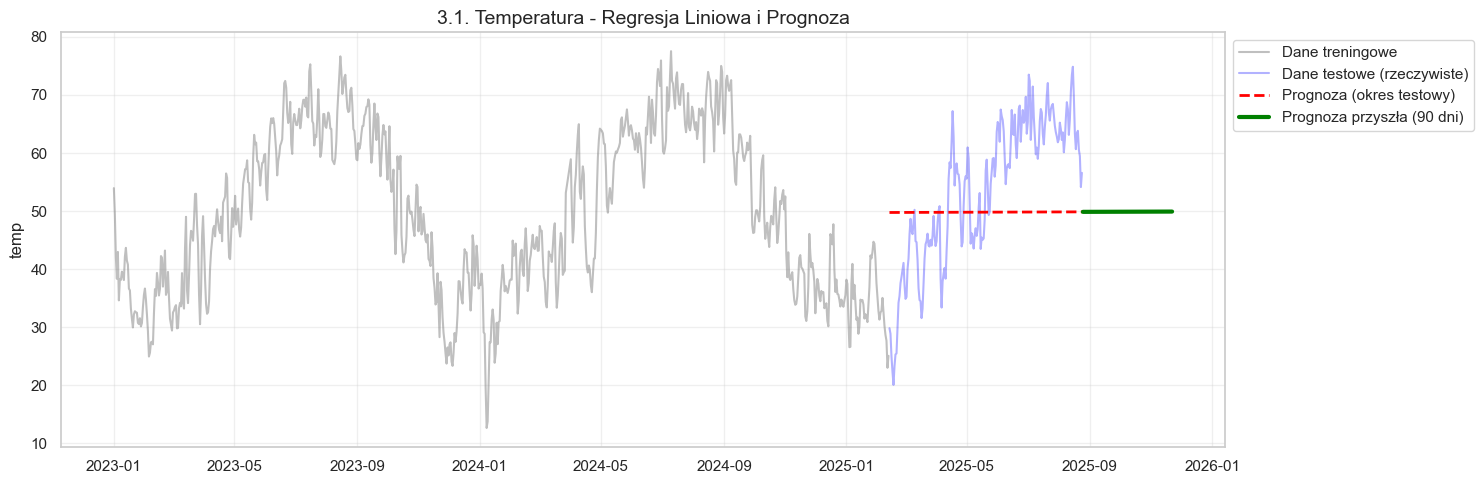

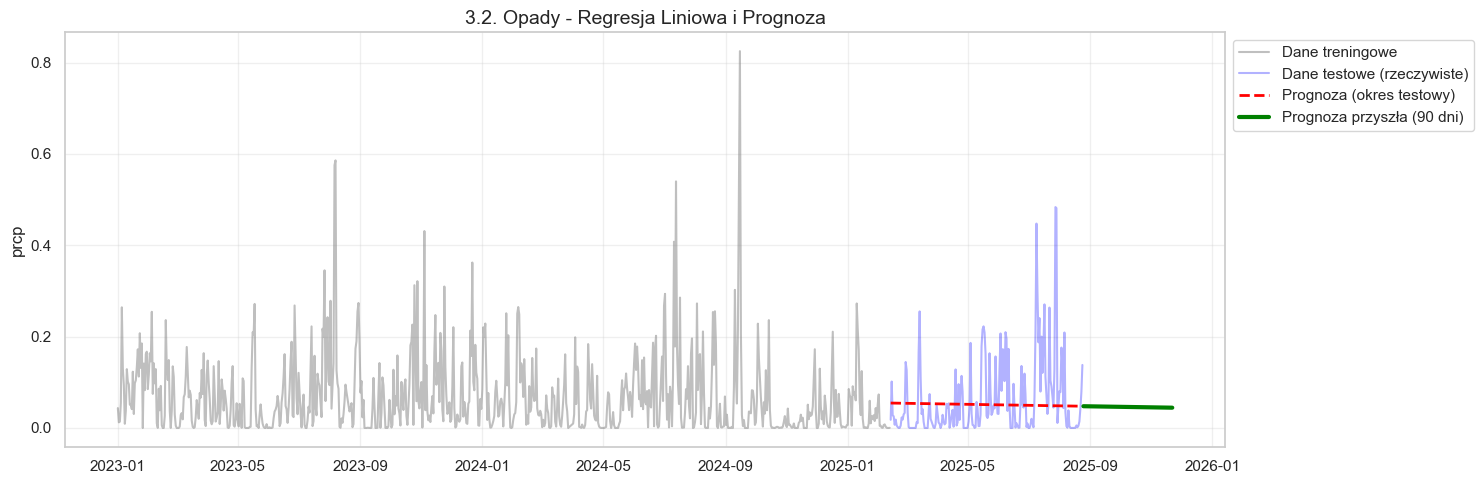

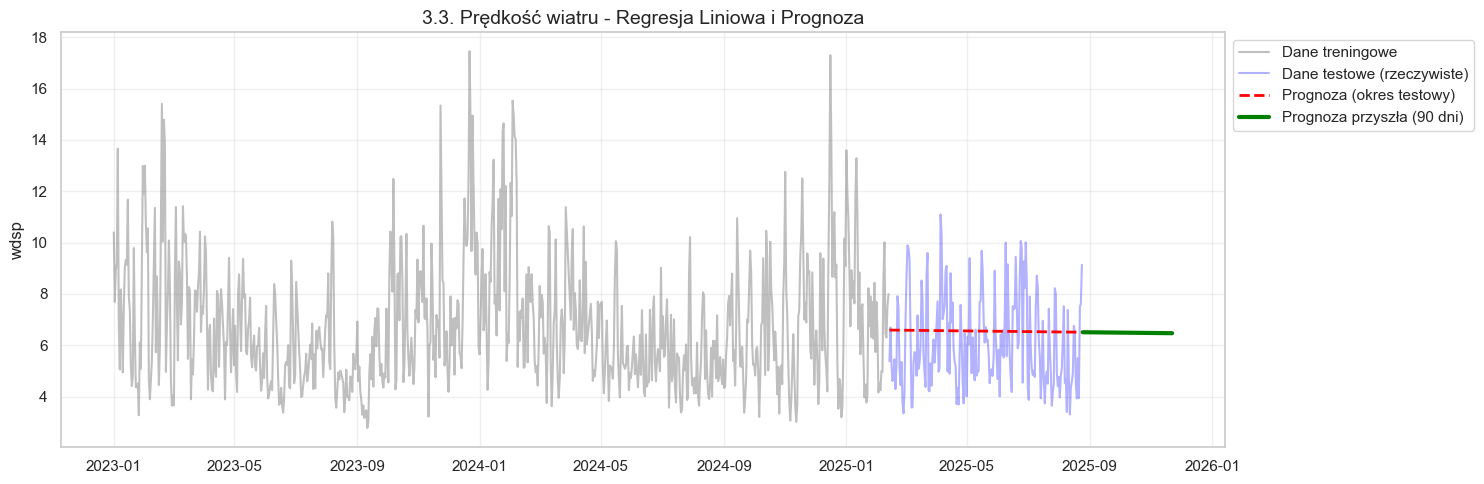

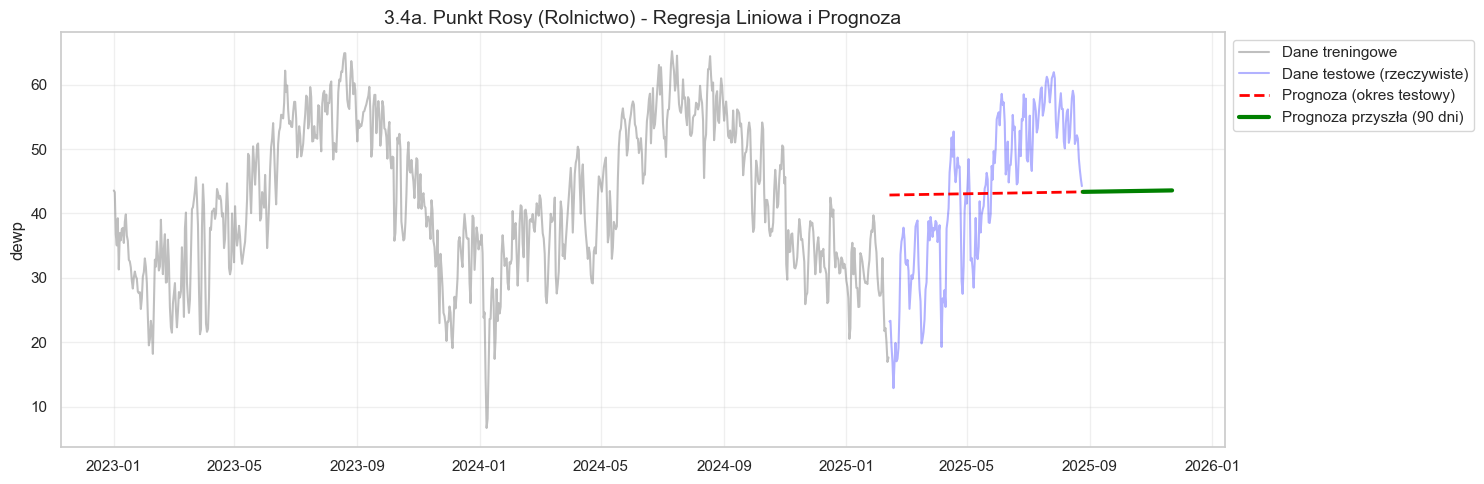

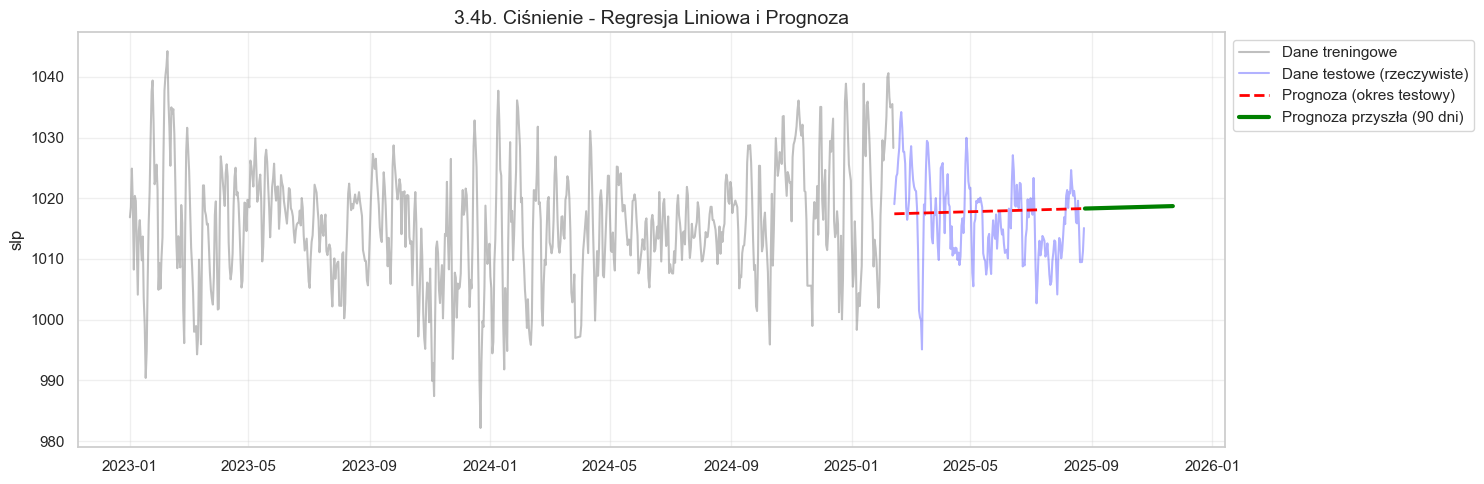

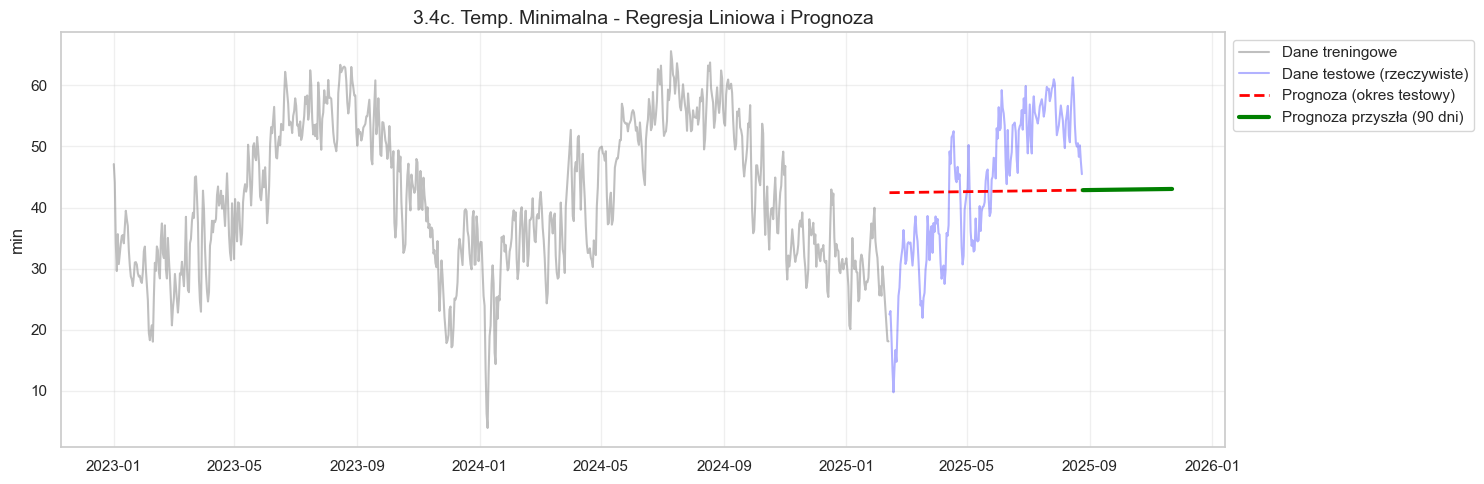

In [7]:
df_reg = data[data['country'] == 'PL'].copy().sort_values('date')
df_reg = df_reg.groupby('date').agg({
    'temp': 'mean', 'prcp': 'mean', 'wdsp': 'mean',
    'dewp': 'mean', 'slp': 'mean', 'min': 'mean'
}).ffill()

# Definiujemy zmienne do analizy
variables = {
    'temp': '3.1. Temperatura',
    'prcp': '3.2. Opady',
    'wdsp': '3.3. Prędkość wiatru',
    'dewp': '3.4a. Punkt Rosy (Rolnictwo)',
    'slp': '3.4b. Ciśnienie',
    'min': '3.4c. Temp. Minimalna'
}

# Podział na zbiór treningowy (80%) i testowy (20%)
split_idx = int(len(df_reg) * 0.8)
train_data = df_reg.iloc[:split_idx]
test_data = df_reg.iloc[split_idx:]

# Przygotowanie osi czasu (liczbowo)
X_train = np.arange(len(train_data)).reshape(-1, 1)
X_test = np.arange(len(train_data), len(df_reg)).reshape(-1, 1)
X_future = np.arange(len(df_reg), len(df_reg) + 90).reshape(-1, 1) # Prognoza na 90 dni w przód

for col, title in variables.items():
    y_train = train_data[col].values

    slope = (np.mean(X_train.flatten() * y_train) - np.mean(X_train) * np.mean(y_train)) / np.var(X_train)
    intercept = np.mean(y_train) - slope * np.mean(X_train)

    y_pred_test = slope * X_test.flatten() + intercept
    y_pred_future = slope * X_future.flatten() + intercept

    plt.figure(figsize=(15, 5))

    plt.plot(train_data.index, y_train, label='Dane treningowe', color='gray', alpha=0.5)

    plt.plot(test_data.index, test_data[col], label='Dane testowe (rzeczywiste)', color='blue', alpha=0.3)

    plt.plot(test_data.index, y_pred_test, label='Prognoza (okres testowy)', color='red', linestyle='--', linewidth=2)

    future_dates = pd.date_range(start=df_reg.index[-1] + pd.Timedelta(days=1), periods=90)
    plt.plot(future_dates, y_pred_future, label='Prognoza przyszła (90 dni)', color='green', linewidth=3)

    plt.title(f"{title} - Regresja Liniowa i Prognoza", fontsize=14)
    plt.ylabel(col)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Zmienna: temp
R2 liniowy: 0.0262
R2 wielomianowy: 0.2825
Najlepszy stopień: 9


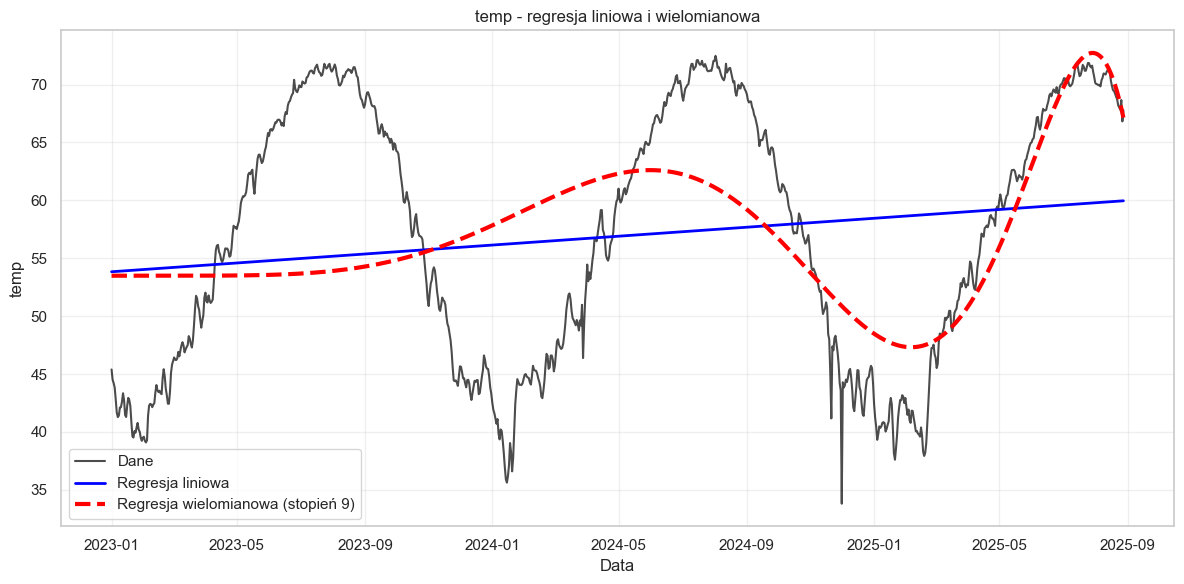


Zmienna: prcp
R2 liniowy: 0.0187
R2 wielomianowy: 0.1682
Najlepszy stopień: 9


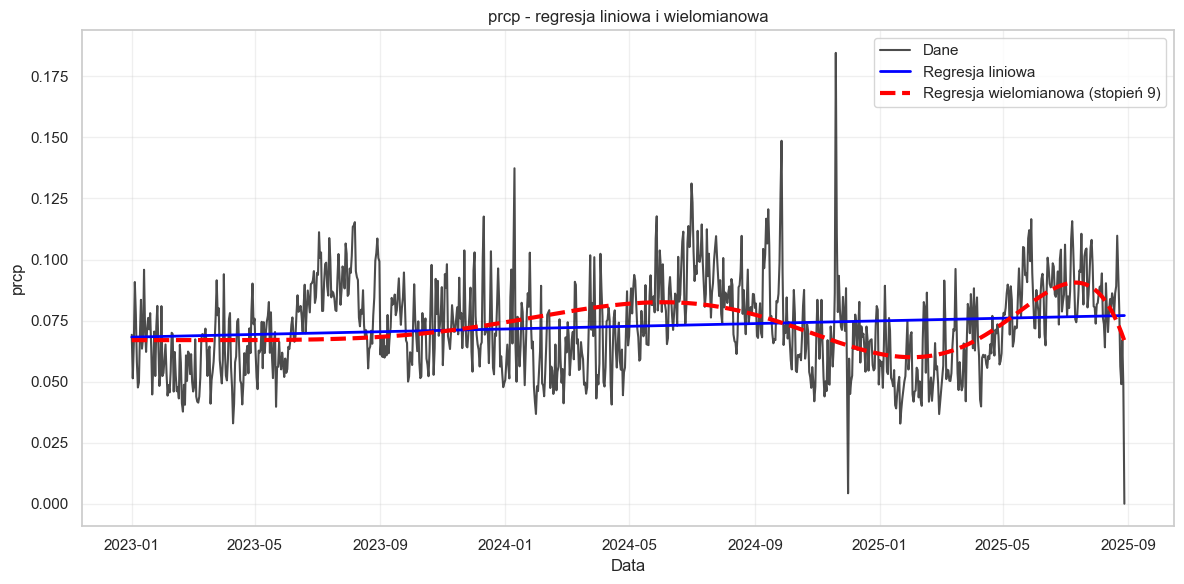


Zmienna: wdsp
R2 liniowy: 0.0073
R2 wielomianowy: 0.1752
Najlepszy stopień: 7


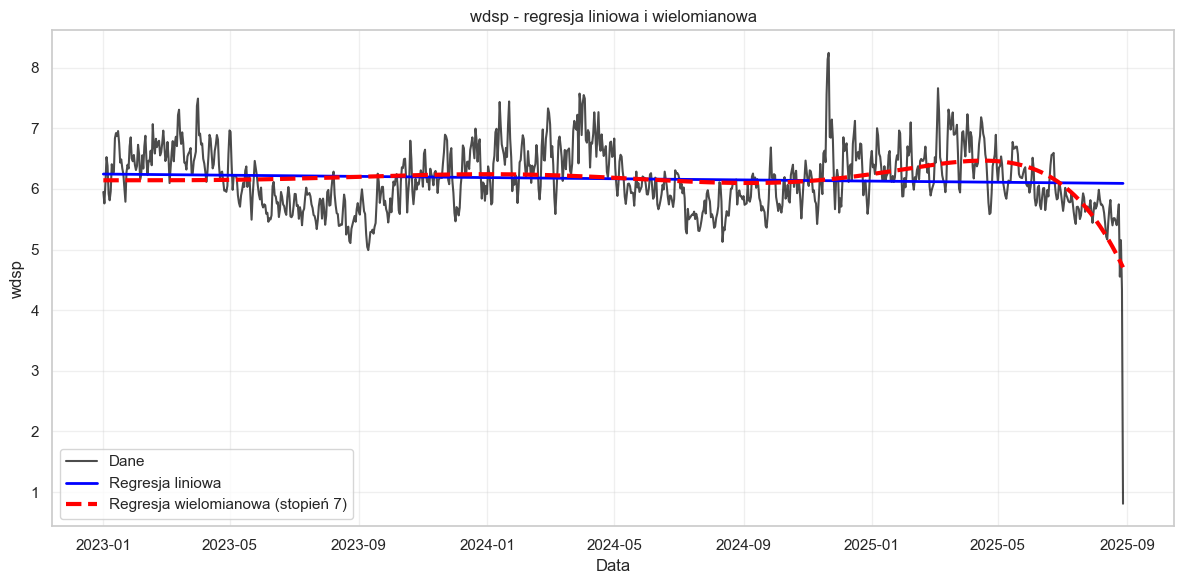


Zmienna: dewp
R2 liniowy: 0.0245
R2 wielomianowy: 0.2906
Najlepszy stopień: 9


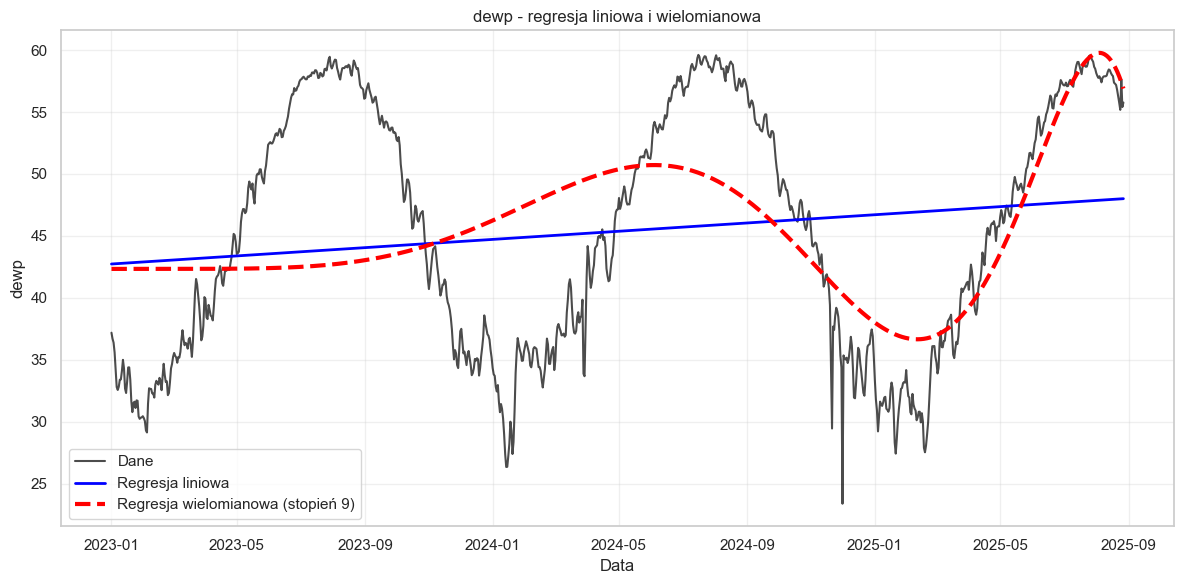


Zmienna: slp
R2 liniowy: 0.0029
R2 wielomianowy: 0.2612
Najlepszy stopień: 9


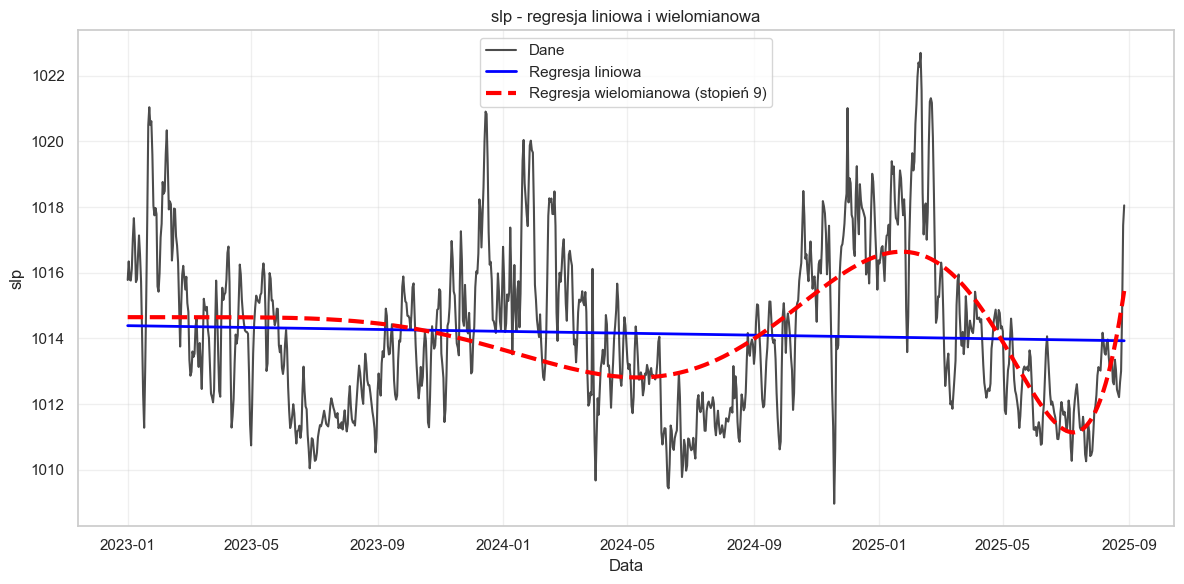

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

zmienne = ['temp', 'prcp', 'wdsp', 'dewp', 'slp']

for zmienna in zmienne:
  df = data[['date', zmienna]].dropna().copy()
  df['date'] = pd.to_datetime(df['date'])

  df = (
      df.groupby('date')[zmienna]
      .mean()
      .reset_index()
  )


  X = np.arange(len(df)).reshape(-1, 1)
  y = df[zmienna].values

  model_lin = LinearRegression()
  model_lin.fit(X, y)
  y_lin = model_lin.predict(X)
  r2_lin = r2_score(y, y_lin)

  best_degree = 2
  best_r2 = -1
  best_model = None

  for degree in range(2, 10):
      model_poly = make_pipeline(PolynomialFeatures(degree),
LinearRegression())
      model_poly.fit(X, y)
      y_poly = model_poly.predict(X)
      r2_poly = r2_score(y, y_poly)

      if r2_poly > best_r2:
          best_r2 = r2_poly
          best_degree = degree
          best_model = model_poly

  y_poly_best = best_model.predict(X)

  print(f'\nZmienna: {zmienna}')
  print(f'R2 liniowy: {r2_lin:.4f}')
  print(f'R2 wielomianowy: {best_r2:.4f}')
  print(f'Najlepszy stopień: {best_degree}')

  plt.figure(figsize=(12, 6))
  plt.plot(df['date'], y, color='black', linewidth=1.5, alpha=0.7,
label='Dane')
  plt.plot(df['date'], y_lin, color='blue', linewidth=2, label='Regresja liniowa')
  plt.plot(df['date'], y_poly_best, color='red', linewidth=3,linestyle='--',label=f'Regresja wielomianowa (stopień {best_degree})')

  plt.title(f'{zmienna} - regresja liniowa i wielomianowa')
  plt.xlabel('Data')
  plt.ylabel(zmienna)
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

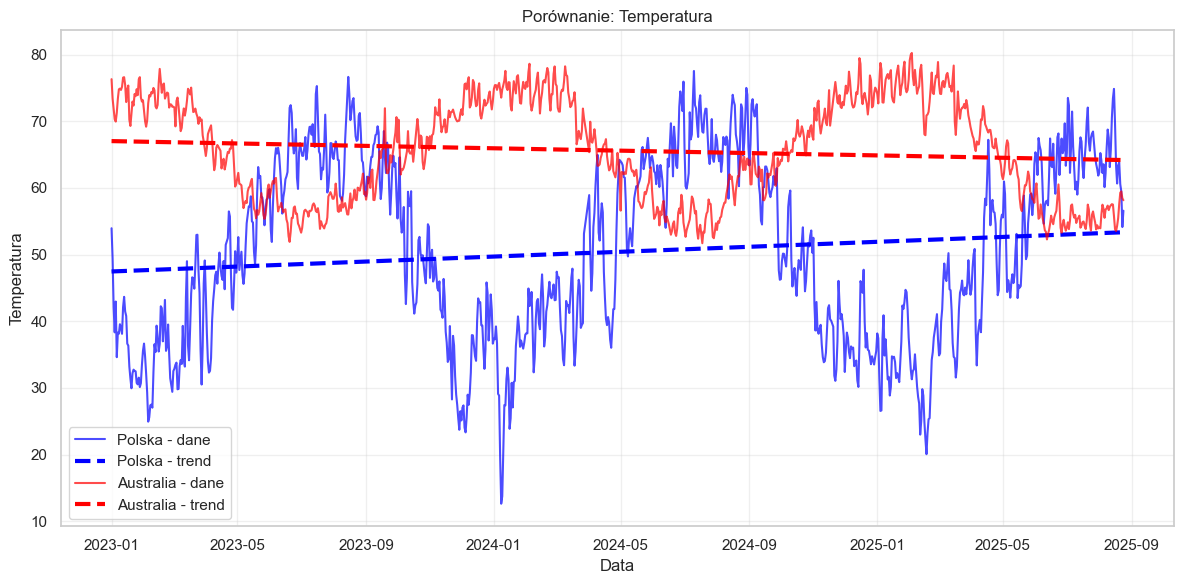

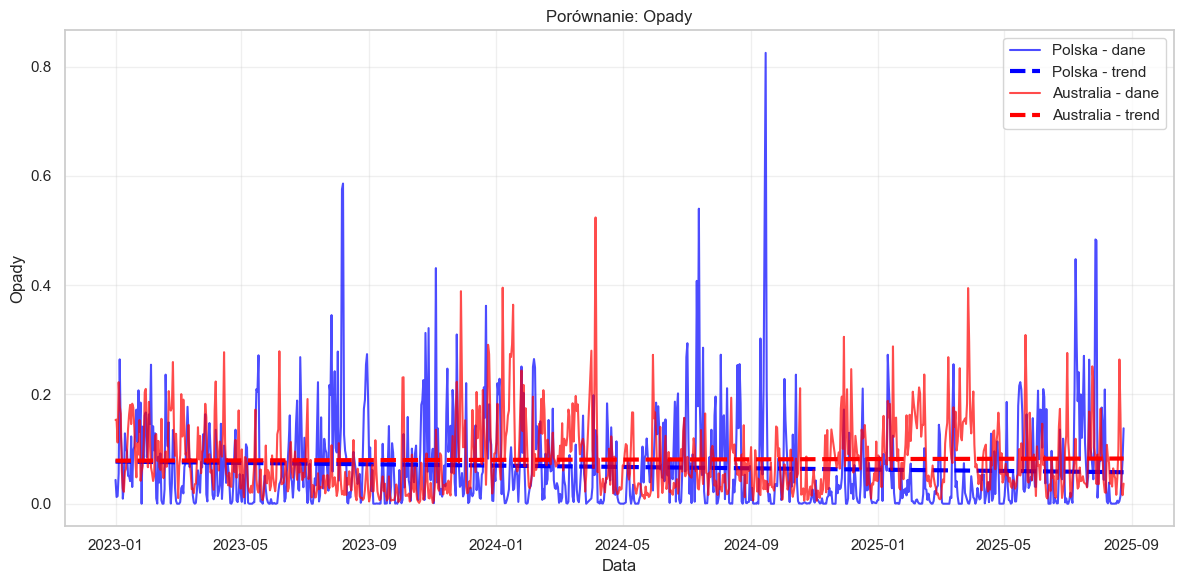

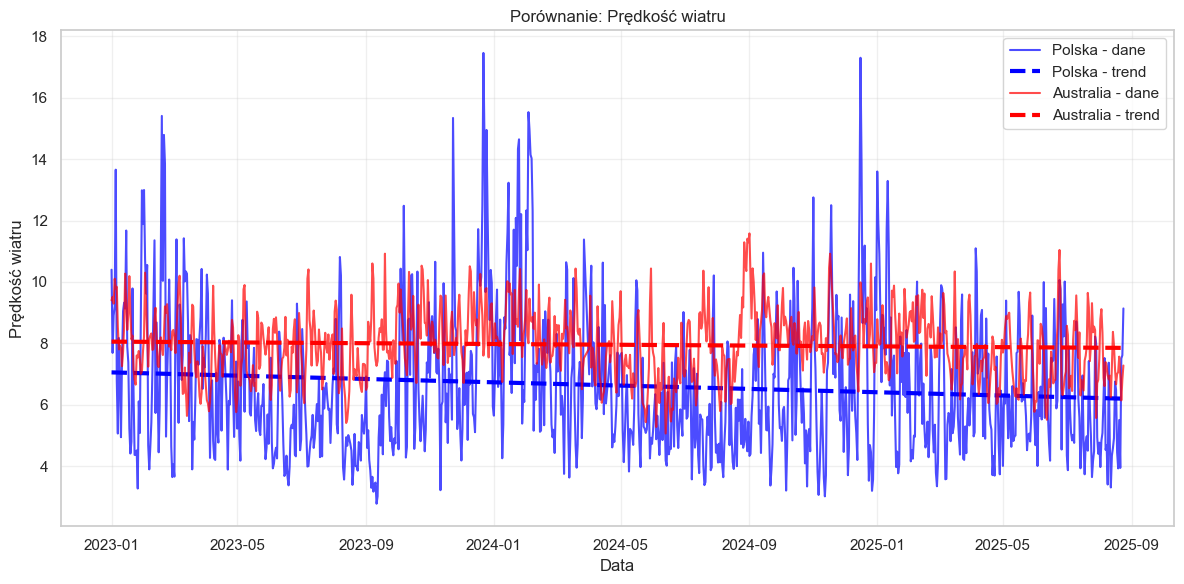

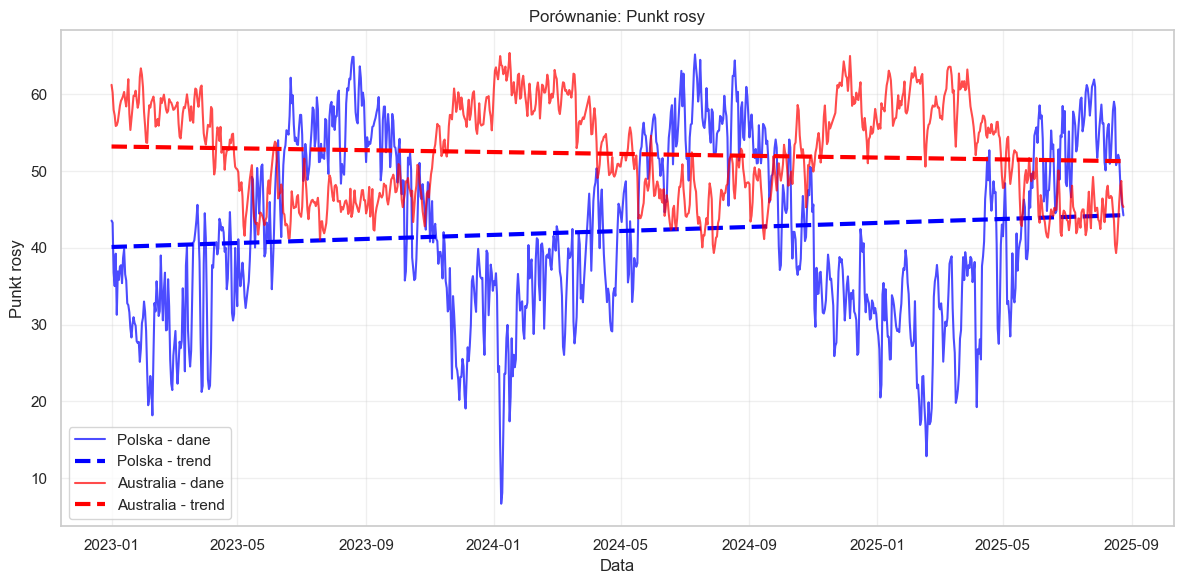

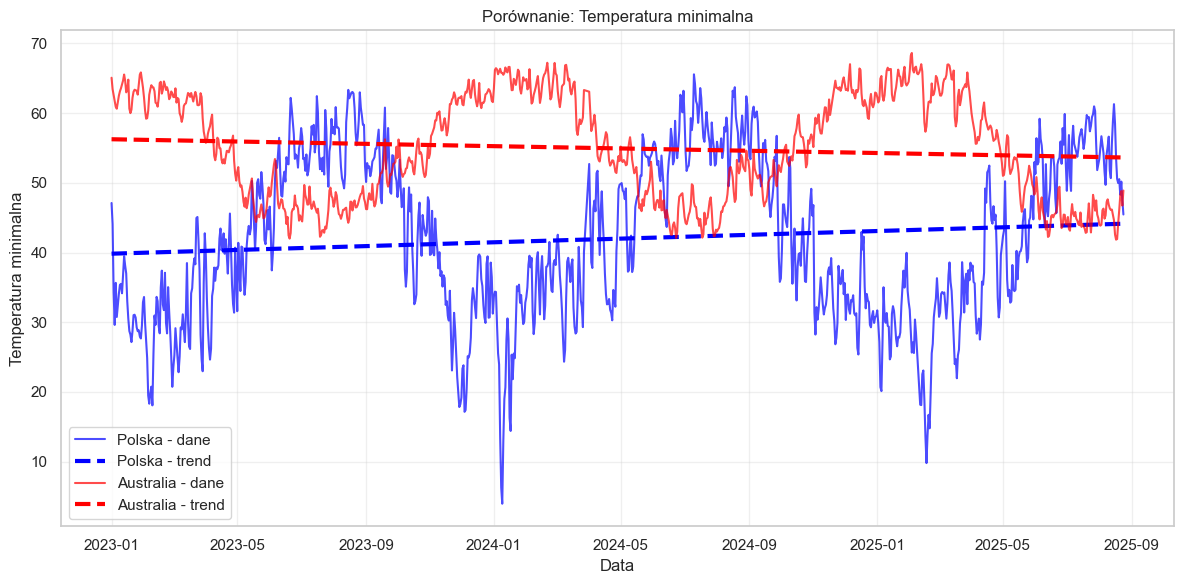

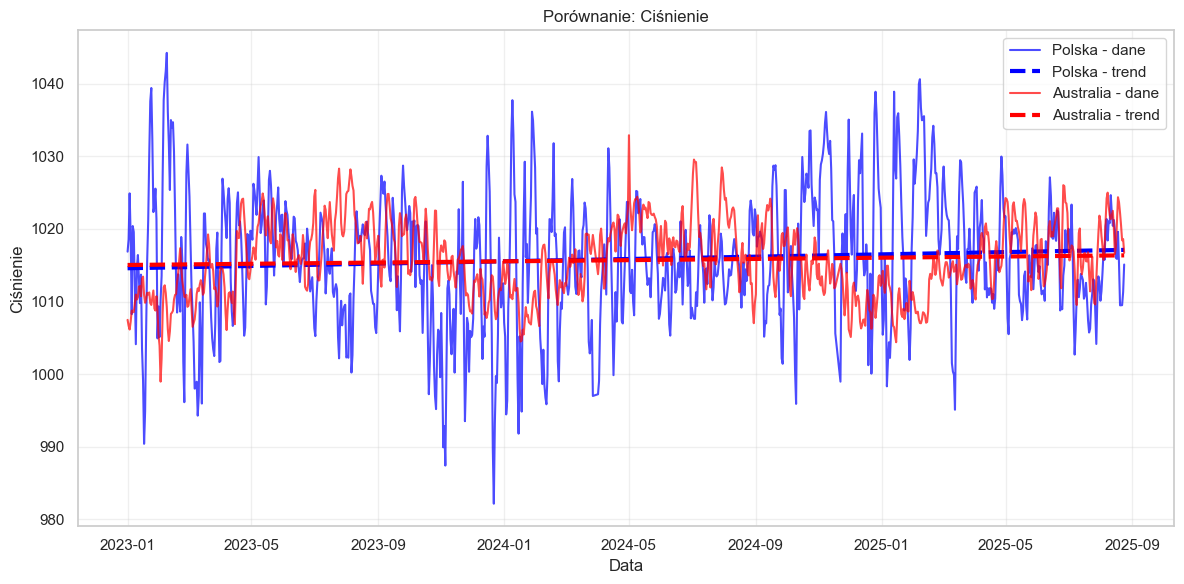

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

kraje = ['PL', 'AS']
zmienne = ['temp', 'prcp', 'wdsp', 'dewp', 'min', 'slp']

opisy = {
  'temp': 'Temperatura',
  'prcp': 'Opady',
  'wdsp': 'Prędkość wiatru',
  'dewp': 'Punkt rosy',
  'min': 'Temperatura minimalna',
  'slp': 'Ciśnienie'
}

nazwy_krajow = {
  'PL': 'Polska',
  'AS': 'Australia'
}

kolory = {
  'PL': 'blue',
  'AS': 'red'
}

for zmienna in zmienne:
  plt.figure(figsize=(12, 6))

  for kraj in kraje:
      df_kraj = data[data['country'] == kraj][['date',
zmienna]].dropna().copy()
      df_kraj['date'] = pd.to_datetime(df_kraj['date'])

      df_kraj = (
          df_kraj.groupby('date')[zmienna]
          .mean()
          .reset_index()
          .sort_values('date')
      )

      X = np.arange(len(df_kraj)).reshape(-1, 1)
      y = df_kraj[zmienna].values

      model = LinearRegression()
      model.fit(X, y)
      trend = model.predict(X)

      plt.plot(
          df_kraj['date'], y,
          color=kolory[kraj],
          linewidth=1.5,
          alpha=0.7,
          label=f'{nazwy_krajow[kraj]} - dane'
      )

      plt.plot(
          df_kraj['date'], trend,
          color=kolory[kraj],
          linestyle='--',
          linewidth=3,
          label=f'{nazwy_krajow[kraj]} - trend'
      )

  plt.title(f'Porównanie: {opisy[zmienna]}')
  plt.xlabel('Data')
  plt.ylabel(opisy[zmienna])
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()